### Import libraries and datasets

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
import keras
import random
import matplotlib.pyplot as plt

from joblib import dump, load
from os import path
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.pyplot import *
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from keras.models import Sequential
from keras import Model, Input, layers, optimizers
from keras.layers import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

Normal training dataset

In [ ]:
# Read the CSV file into a DataFrame
path = r'../CIC-IDS/CSV-2023/MERGED_CSV'
all_files = glob.glob(path + "/*.csv")
li = []
for i in range(45):
    df = pd.read_csv(all_files[i], encoding='cp1252', index_col=None, header=0)
    li.append(df)
    print("Read Completed for ", all_files[i])
df = pd.concat(li, axis=0, ignore_index=True)
df.describe()
df.head()
df.info()

Filtered, categorized data by labels for more customized training

In [2]:
# Attack data
Label_path = r'../Label_CSV'
rows = 200000
# rows = 300000
# Label_path = r'../Label_CSV'
# Brute_Force = pd.read_csv(Label_path + '/Brute_Force.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
# print("Read Completed for ", Label_path + '/Brute_Force.csv')
DDoS = pd.read_csv(Label_path + '/DDoS.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/DDoS.csv')
DoS = pd.read_csv(Label_path + '/DoS.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/DoS.csv')
Spoofing = pd.read_csv(Label_path + '/Spoofing.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Spoofing.csv')
Recon = pd.read_csv(Label_path + '/Recon.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Recon.csv')
Web_based = pd.read_csv(Label_path + '/Web_based.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Web_based.csv')
Mirai = pd.read_csv(Label_path + '/Mirai.csv', encoding='cp1252', index_col=None, header=0, nrows=rows)
print("Read Completed for ", Label_path + '/Mirai.csv')
list_attack = [DDoS, DoS, Spoofing, Recon, Mirai, Web_based]
attack = pd.concat(list_attack, axis=0, ignore_index=True)
attack = attack.sample(frac=1, random_state=42).reset_index(drop=True)
label_series = pd.Series(attack['Label'])
print(label_series.value_counts())


# Normal data
path = r'../normal_traffic_cap_live'
all_normal_files = glob.glob(path + "/*.csv")
list_normal = []
for file in all_normal_files:
    normal = pd.read_csv(file, encoding='cp1252', index_col=None, header=0)
    list_normal.append(normal)
    print("Read Completed for ", file)
normal = pd.concat(list_normal, axis=0, ignore_index=True)
normal = normal.sample(frac=1, random_state=42).reset_index(drop=True)
normal['Label'] = 0
normal.drop_duplicates(keep='first', inplace = True)
normal.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
normal.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
normal.reset_index(drop=True, inplace=True)
# normal = pd.read_csv('../Label_CSV/BENIGN.csv')
# normal = pd.read_csv('c:/Users/ADMIN/Downloads/live_features.csv')

print("Normal: ",normal.shape)
print("Attack: ",attack.shape)

Read Completed for  ../Label_CSV/DDoS.csv
Read Completed for  ../Label_CSV/DoS.csv
Read Completed for  ../Label_CSV/Spoofing.csv
Read Completed for  ../Label_CSV/Recon.csv
Read Completed for  ../Label_CSV/Web_based.csv
Read Completed for  ../Label_CSV/Mirai.csv
Label
Recon        200000
Mirai        200000
DDoS         200000
DoS          200000
Spoofing     187208
Web_based     16053
Name: count, dtype: int64
Read Completed for  ../normal_traffic_cap_live\network_data.csv
Read Completed for  ../normal_traffic_cap_live\network_data_2.csv
Read Completed for  ../normal_traffic_cap_live\network_data_4.csv
Read Completed for  ../normal_traffic_cap_live\network_data_5.csv
Read Completed for  ../normal_traffic_cap_live\network_data_7.csv
Read Completed for  ../normal_traffic_cap_live\network_data_8.csv
Read Completed for  ../normal_traffic_cap_live\network_data_rmit.csv
Normal:  (1032152, 40)
Attack:  (1003261, 40)


### 1st satge model (binary classification)

Ensure column align

In [5]:
common_columns = attack.columns.intersection(normal.columns)
attack = attack[common_columns]
normal = normal[common_columns]

Visual Compare Feature Distributions

In [ ]:
for col in common_columns.drop(['Label']):
    print(col)
    print("Normal: ", len(normal[col]))
    print("Attack: ", len(attack[col]))
    plt.figure(figsize=(10,4))
    sns.kdeplot(normal[col], label='Normal traffic', fill=True)
    sns.kdeplot(attack[col], label='Attack traffic', fill=True)
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

In [3]:
dropped_columns =['fin_flag_number', 'rst_flag_number', 'ece_flag_number', 'cwr_flag_number', 'fin_count', 'rst_count', 'HTTP', 'Telnet', 'SMTP', 'SSH', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'LLC', 'IPv']
# dropped_columns =[]
# 'Number'
# 'Time_To_Live', 'Min'
# Rate
# ack_flag_number 
# TCP
# ack_count
# UDP
# Number
# DNS
# IRC
# Protocol Type
# psh_flag_number
# syn_count
# syn_flag_number


Grouping main categories into one category for binary classification

In [4]:
def limit(data):
    limits = round((data.shape[0]*90)/100)
    return limits

attack_train = pd.concat([DDoS[:limit(DDoS)], DoS[:limit(DoS)], Mirai[:limit(Mirai)], Web_based[:limit(Web_based)], 
                          Spoofing[:limit(Spoofing)], Recon[:limit(Recon)]], axis=0, ignore_index=True)
attack_train = attack_train.drop(columns=dropped_columns)
print("Training attack data: ",attack_train.shape)


attack_test = pd.concat([DDoS[limit(DDoS):DDoS.shape[0]], DoS[limit(DoS):DoS.shape[0]], Mirai[limit(Mirai):Mirai.shape[0]], 
                         Web_based[limit(Web_based):Web_based.shape[0]], Spoofing[limit(Spoofing):Spoofing.shape[0]], 
                         Recon[limit(Recon):Recon.shape[0]]], axis=0, ignore_index=True)
attack_test = attack_test.drop(columns=dropped_columns)
print("Testing attack data: ",attack_test.shape)

Training attack data:  (902935, 24)
Testing attack data:  (100326, 24)


In [5]:
# Grouping
Attack = ['DDoS', 'Web_based', 'DoS', 'Brute_Force', 'Recon', 'Spoofing', 'Mirai']

def classify_attacks(data):
    data['Label'] = data['Label'].replace(Attack, 1)
    # Ensure labels are integers
    data['Label'] = data['Label'].astype(int)
classify_attacks(attack_train)
classify_attacks(attack_test)

In [6]:
normal = normal.drop(columns=dropped_columns)
print("Normal data: ",normal.shape)
limits = round(normal.shape[0]*90/100)
normal_train = normal[0:limits] 
print("Training normal data: ",normal_train.shape)
normal_test = normal[limits:normal.shape[0]]
print("Testing normal data: ",normal_test.shape)

Normal data:  (1032152, 24)
Training normal data:  (928937, 24)
Testing normal data:  (103215, 24)


In [7]:
df = pd.concat([attack_train, normal_train], axis=0, ignore_index=True)
# df = normal_train.drop(columns=['Label'])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.describe()
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1831872 entries, 0 to 1831871
Data columns (total 24 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Header_Length    float64
 1   Protocol Type    int64  
 2   Time_To_Live     float64
 3   Rate             float64
 4   syn_flag_number  float64
 5   psh_flag_number  float64
 6   ack_flag_number  float64
 7   ack_count        int64  
 8   syn_count        int64  
 9   HTTPS            float64
 10  DNS              float64
 11  IRC              float64
 12  TCP              float64
 13  UDP              float64
 14  Tot sum          int64  
 15  Min              int64  
 16  Max              int64  
 17  AVG              float64
 18  Std              float64
 19  Tot size         int64  
 20  IAT              float64
 21  Number           int64  
 22  Variance         float64
 23  Label            int64  
dtypes: float64(15), int64(9)
memory usage: 335.4 MB


In [ ]:
df['Label'].value_counts()

These are the sub-cat that underperforming according to the Random Forest model (Also drop the BENIGN since we use our own BENIGN)

In [ ]:
delete_cat = ['DDOS-RSTFINFLOOD', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'RECON-OSSCAN', 'RECON-PORTSCAN', 'BENIGN']

df = df[~df['Label'].isin(delete_cat)].reset_index(drop=True)

Grouping sub-categories into one category for binary classification

In [ ]:
# Grouping
Attack = ['DDOS-ACK_FRAGMENTATION',     
        'DDOS-UDP_FLOOD',       
        'DDOS-SLOWLORIS',               
        'DDOS-ICMP_FLOOD',     
        'DDOS-PSHACK_FLOOD',        
        'DDOS-HTTP_FLOOD',              
        'DDOS-UDP_FRAGMENTATION',         
        'DDOS-ICMP_FRAGMENTATION',
        'DDOS-RSTFINFLOOD', 
        'DDOS-SYNONYMOUSIP_FLOOD', 
        'DDOS-SYN_FLOOD', 
        'DDOS-TCP_FLOOD',
        'DOS-UDP_FLOOD',       
        'DOS-HTTP_FLOOD',
        'DOS-SYN_FLOOD', 
        'DOS-TCP_FLOOD',
        'MITM-ARPSPOOFING',     
        'DNS_SPOOFING',
        'DICTIONARYBRUTEFORCE',
        'RECON-HOSTDISCOVERY',                
        'RECON-PINGSWEEP',
        'RECON-OSSCAN', 
        'RECON-PORTSCAN',       
        'VULNERABILITYSCAN',
        'SQLINJECTION',        
        'BROWSERHIJACKING',         
        'COMMANDINJECTION',       
        'XSS',         
        'BACKDOOR_MALWARE',          
        'UPLOADING_ATTACK',
        'MIRAI-GREETH_FLOOD',     
        'MIRAI-UDPPLAIN',     
        'MIRAI-GREIP_FLOOD']

def classify_attacks(data):
    data['Label'].replace(Attack,1,inplace=True)
classify_attacks(df)

In [ ]:
df = pd.concat([df, normal_train], axis=0, ignore_index=True)
# df = normal_train.drop(columns=['Label'])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.describe()
df.head()
df.info()

In [ ]:
df['Label'].value_counts()

Grouping sub-category into main categories for multiclass classification

In [ ]:
# Grouping
DDoS = ['DDOS-ACK_FRAGMENTATION',     
        'DDOS-UDP_FLOOD',       
        'DDOS-SLOWLORIS',               
        'DDOS-ICMP_FLOOD',        
        'DDOS-RSTFINFLOOD',    
        'DDOS-PSHACK_FLOOD',        
        'DDOS-HTTP_FLOOD',              
        'DDOS-UDP_FRAGMENTATION',     
        'DDOS-TCP_FLOOD',  
        'DDOS-SYN_FLOOD',        
        'DDOS-SYNONYMOUSIP_FLOOD',    
        'DDOS-ICMP_FRAGMENTATION']

DoS = ['DOS-UDP_FLOOD',    
       'DOS-TCP_FLOOD',    
       'DOS-SYN_FLOOD',    
       'DOS-HTTP_FLOOD']

Spoofing = ['MITM-ARPSPOOFING',     
            'DNS_SPOOFING']

Brute_Force = ['DICTIONARYBRUTEFORCE']

Recon = ['RECON-HOSTDISCOVERY', 
         'RECON-OSSCAN',     
         'RECON-PORTSCAN',               
         'RECON-PINGSWEEP',         
         'VULNERABILITYSCAN']

Web_based = ['SQLINJECTION',        
             'BROWSERHIJACKING',         
             'COMMANDINJECTION',       
             'XSS',         
             'BACKDOOR_MALWARE',          
             'UPLOADING_ATTACK']

Mirai = ['MIRAI-GREETH_FLOOD',     
         'MIRAI-UDPPLAIN',     
         'MIRAI-GREIP_FLOOD']



def classify_attacks(data):
    data['Label'].replace(DDoS,'DDoS',inplace=True)
    data['Label'].replace(DoS,'DoS',inplace=True)
    data['Label'].replace(Spoofing,'Spoofing',inplace=True)
    data['Label'].replace(Brute_Force,'Brute_Force',inplace=True)
    data['Label'].replace(Recon,'Recon',inplace=True)
    data['Label'].replace(Web_based,'Web_based',inplace=True)
    data['Label'].replace(Mirai,'Mirai',inplace=True)
classify_attacks(df)

In [ ]:
# Train set preprocessing
df.drop_duplicates(keep='first', inplace = True)
df.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
df.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
df.reset_index(drop=True, inplace=True)

Export csv that contain only 1 label

In [ ]:
category_counts = df["Label"].value_counts()
category_names = category_counts.index.tolist()

for cat in category_names:
    csv_by_label = df[df['Label'] == cat]
    csv_by_label.to_csv('../2nd_Label_CSV/{}.csv'.format(cat), index=False)

In [9]:
columns_name = df.drop(columns=['Label']).columns

In [ ]:
X_train_val = df

In [8]:
# Create train data
X_train_val = df.drop(columns=['Label'])
Y_train_val = df['Label']

In [10]:
print(X_train_val.shape)
print(Y_train_val.shape)

(1831872, 23)
(1831872,)


In [11]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
0    928937
1    902935
Name: count, dtype: int64


In [11]:
# Under sampling
undersample = RandomUnderSampler(sampling_strategy='all') # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
                                                            # the target undersample - in this case '2' is the name of the 'DDOS' after encoded


X_train_val, Y_train_val = undersample.fit_resample(X_train_val, Y_train_val)

In [ ]:
# Over sampling
sm = SMOTE()
X_train_val, Y_train_val = sm.fit_resample(X_train_val, Y_train_val)

print(Y_train_val.shape)
print(X_train_val.shape)

In [102]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
0    928937
1    902935
Name: count, dtype: int64


In [89]:
# scaler = StandardScaler()
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_val)
#X_test_scaled = scaler.fit_transform(X_test)

In [12]:
X_train_scaled = X_train_val

In [36]:
import joblib
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [13]:
# Split the data set into training and testing
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_scaled, Y_train_val, test_size=0.2, random_state=33, shuffle=True)

In [20]:
X_train

,Header_Length,Protocol Type,Time_To_Live,Rate,syn_flag_number,psh_flag_number,ack_flag_number,ack_count,syn_count,HTTPS,...,UDP,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance
1461365,28.0,17,255.000000,0.728522,0.00,0.000000,0.00,0,0,0.0,...,1.0,1095,225,435,365.000000,121.243557,1095,0.001723,3,14700.000000
19182,28.0,17,255.000000,0.680986,0.00,0.000000,0.00,0,0,0.0,...,1.0,668,167,167,167.000000,0.000000,668,0.000789,4,0.000000
254147,28.0,17,255.000000,0.245122,0.00,0.000000,0.00,0,0,0.0,...,1.0,856,214,214,214.000000,0.000000,856,0.009597,4,0.000000
1510009,28.0,17,255.000000,1.215969,0.00,0.000000,0.00,0,0,0.0,...,1.0,1010,164,424,252.500000,122.620009,1010,0.005732,4,15035.666667
218217,28.0,17,255.000000,1.921877,0.00,0.000000,0.00,0,0,0.0,...,1.0,5119,214,1487,731.285714,585.460136,5119,0.007136,7,342763.571429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1207497,40.0,6,125.714286,11.646480,0.00,0.657143,1.00,35,0,1.0,...,0.0,5745,54,553,164.142857,156.952998,5745,0.003908,35,24634.243697
1272466,28.0,17,121.666667,0.009666,0.00,0.000000,0.00,0,0,0.0,...,1.0,270,90,90,90.000000,0.000000,270,0.015555,3,0.000000
1442370,28.0,17,255.000000,0.928163,0.00,0.000000,0.00,0,0,0.0,...,1.0,2260,191,1167,565.000000,419.631584,2260,0.021238,4,176090.666667
1152728,57.4,6,64.000000,1043.743468,0.87,0.000000,0.13,13,87,0.0,...,0.0,7218,60,74,72.180000,4.731967,7218,0.000170,100,22.391515


#### Neural Network

In [ ]:
_features = X_train.shape[1]

In [ ]:
nn_model = Sequential([
    Input(shape=(_features,)),

    # CNN layer structure
    # Convolution1D(256, 6, activation='relu'),
    # layers.BatchNormalization(),
    # MaxPooling1D(2),
    # Convolution1D(128, 6, activation='relu'),
    # layers.BatchNormalization(),
    # UpSampling1D(3),
    # Convolution1D(256, 6, activation='relu'),
    # Flatten(), # Maybe when we don't use lstm
    
    # LSTM layer structure
    # LSTM(512, return_sequences=False),
    # Dense(256, activation='relu'),
    
    # FNN layer structure
    Dense(256, activation='relu'), # Already have a Dense above
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Classification layer
    Dense(1, activation='sigmoid'),  # Softmax for multiclass, Sigmoid for binary, both use as output layer. Also, binary classification only have one output
])

In [ ]:
nn_model.summary()

In [ ]:
opt = optimizers.Adam(learning_rate=0.0001)
nn_model.compile(loss='binary_crossentropy',optimizer=opt, metrics=['accuracy'])
early_stop_callback = keras.callbacks.EarlyStopping(monitor='loss', patience=5)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                  patience=3, min_lr=0.0001)

In [ ]:
start_fit = time.time()
history = nn_model.fit(X_train, Y_train,
                              batch_size=128,
                              epochs=10,
                              verbose=True,
                              validation_data=(X_val, Y_val))    

end_fit = time.time()
fit_time = end_fit - start_fit
print("fit time: {:.2f} seconds".format(fit_time))  

In [ ]:
test_set = pd.concat([attack_test, normal_test], axis=0, ignore_index=True)
# test_set = normal_train.drop(columns=['Label'])
test_set = test_set.sample(frac=1, random_state=42).reset_index(drop=True)

test_set.drop_duplicates(keep='first', inplace = True)
test_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
test_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
test_set.reset_index(drop=True, inplace=True)

# Create test data
X_test = test_set.drop(columns=['Label'])
Y_test = test_set['Label']

y_pred_nn = nn_model.predict(X_test)
# y_pred_nn will be probabilities in [0,1]
y_pred_labels = (y_pred_nn > 0.5).astype(int).flatten()
print(classification_report(Y_test, y_pred_labels))

In [ ]:
# Test set preprocessing
normal_test.drop_duplicates(keep='first', inplace = True)
normal_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
normal_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
normal_test.reset_index(drop=True, inplace=True)

X_sample = normal_test.drop(columns=['Label'])
Y_sample = normal_test['Label']

test_scaler = MinMaxScaler()
X_sample_scaled = test_scaler.fit_transform(X_sample)

score = 0
total = 1000

for i in range(total):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[-i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = nn_model.predict(sample)[0]
    pred_labels = (pred > 0.5).astype(int).flatten()
    actual = Y_sample.iloc[-i]

    if pred_labels == actual:
        score += 1
        
    print(f"Sample {-i}: Predicted = {pred_labels}, Actual = {actual}")

print("Percentage: ", (score/total)*100)

In [ ]:
attack_sample = DDoS.drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 'rst_count', 'Telnet', 'SMTP', 'SSH', 'IRC', 'ARP', 'IGMP', 'LLC', 'IAT', 'Number'])
# attack_sample = attack_test
# Test set preprocessing
attack_sample.drop_duplicates(keep='first', inplace = True)
attack_sample.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_sample.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_sample.reset_index(drop=True, inplace=True)

X_sample = attack_sample.drop(columns=['Label'])
Y_sample = attack_sample['Label']

test_scaler = MinMaxScaler()
X_sample_scaled = test_scaler.fit_transform(X_sample)

score = 0
total = 500

for i in range(total):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[-i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = nn_model.predict(sample)[0]
    pred_labels = (pred > 0.5).astype(int).flatten()
    actual = Y_sample.iloc[-i]

    if pred_labels == actual:
        score += 1
        
    print(f"Sample {-i}: Predicted = {pred_labels}, Actual = {actual}")

print("Percentage: ", (score/total)*100)

#### Random Forest

In [21]:
frst_model = RandomForestClassifier(n_estimators=100,       # Default (reduce to 50-80 if too slow)
                                    max_depth=15,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=20,   # Reduce splits on small nodes
                                    min_samples_leaf=20,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    class_weight="balanced",
                                    n_jobs=-1,              # Use all CPU cores
                                    #verbose=1,              # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=20, min_samples_split=20, n_jobs=-1,
                       random_state=42)

In [23]:
y_pred_frst = frst_model.predict(X_val)
print(classification_report(Y_val, y_pred_frst))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    186086
           1       1.00      0.99      0.99    180289

    accuracy                           0.99    366375
   macro avg       0.99      0.99      0.99    366375
weighted avg       0.99      0.99      0.99    366375



In [24]:
test_set = pd.concat([attack_test, normal_test], axis=0, ignore_index=True)
# test_set = normal_train.drop(columns=['Label'])
test_set = test_set.sample(frac=1, random_state=42).reset_index(drop=True)
print("Testing data: ", test_set.shape)

# Create test data
X_test = test_set.drop(columns=['Label'])
# X_test = scaler.transform(X_test) 
Y_test = test_set['Label']

Testing data:  (203541, 24)


In [ ]:
# Under sampling
undersample = RandomUnderSampler(sampling_strategy='all') # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 

X_test, Y_test = undersample.fit_resample(X_test, Y_test)

In [25]:
y_pred_frst = frst_model.predict(X_test)
print(classification_report(Y_test, y_pred_frst))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    103215
           1       1.00      0.99      0.99    100326

    accuracy                           0.99    203541
   macro avg       0.99      0.99      0.99    203541
weighted avg       0.99      0.99      0.99    203541



Time_To_Live       1.806327e-01
Min                1.279399e-01
Header_Length      9.587230e-02
Variance           9.336131e-02
Std                9.099299e-02
IAT                8.021580e-02
Rate               5.418358e-02
Max                4.972257e-02
AVG                3.684373e-02
HTTPS              2.820777e-02
Tot sum            2.179150e-02
Tot size           2.103165e-02
DNS                1.870966e-02
ack_count          1.445701e-02
UDP                1.298214e-02
ack_flag_number    1.148373e-02
psh_flag_number    1.125904e-02
Number             9.267677e-03
TCP                8.840515e-03
IRC                8.598819e-03
Protocol Type      8.227596e-03
syn_flag_number    5.226834e-03
syn_count          2.918152e-03
fin_flag_number    1.580266e-03
DHCP               1.431710e-03
HTTP               1.333486e-03
fin_count          1.111715e-03
rst_flag_number    1.039460e-03
rst_count          5.282155e-04
ece_flag_number    1.178133e-04
cwr_flag_number    8.953427e-05
SSH     

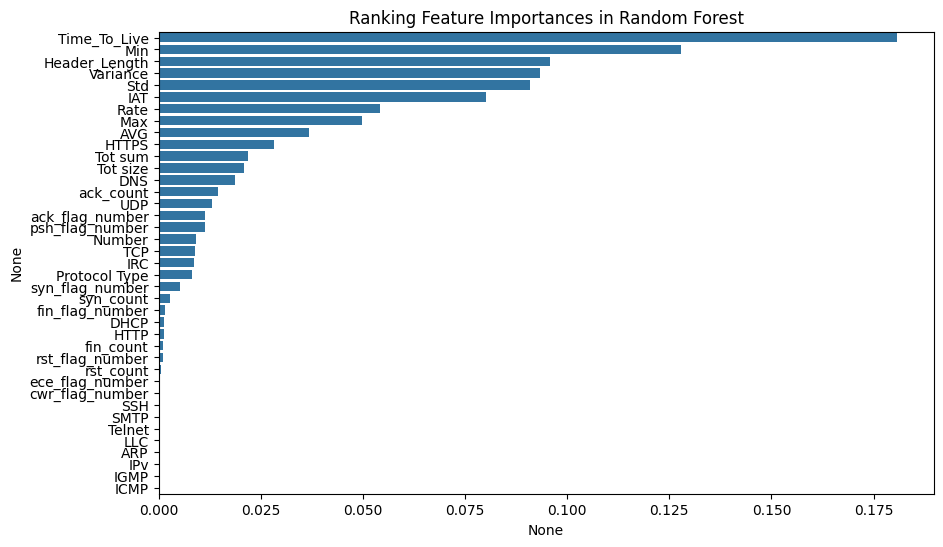

In [18]:
# Check feature importance
feat_importances = pd.Series(frst_model.feature_importances_, index=columns_name)
top_features = feat_importances.sort_values(ascending=False)
print(top_features)
plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Ranking Feature Importances in Random Forest")
plt.show()

In [29]:
# Save the model
with open('../Models/CIC_models/new_frst_model_1st_stage.pkl', 'wb') as f:
    pickle.dump(frst_model, f)

In [14]:
# Load the model
with open('../Models/CIC_models/new_frst_model_1st_stage.pkl', 'rb') as f:
    frst_model = pickle.load(f)

In [26]:
test = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_backend/network_data.csv', encoding='cp1252', index_col=None, header=0, nrows=rows).drop(columns=dropped_columns)
# test = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/network_logger/network_data.csv', encoding='cp1252', index_col=None, header=0, nrows=rows).drop(columns=dropped_columns)
# test = pd.read_csv('C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/Capstone_Project_model/normal_traffic_cap_live/network_data_8.csv', encoding='cp1252', index_col=None, header=0, nrows=rows).drop(columns=dropped_columns)

# test_scaled = scaler.fit_transform(test)
test_scaled = test

score = 0

for i in range(100):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = test_scaled.iloc[[i]]  #If scaler is includeed, always reshape the data
    # print(sample)
    pred = frst_model.predict(sample)[0]
    if pred == 0:
        score += 1
    print(f"Sample {i}: Predicted = {pred}")
print("Percentage: ", score)

Sample 0: Predicted = 0
Sample 1: Predicted = 0
Sample 2: Predicted = 0
Sample 3: Predicted = 0
Sample 4: Predicted = 0
Sample 5: Predicted = 0
Sample 6: Predicted = 0
Sample 7: Predicted = 0
Sample 8: Predicted = 0
Sample 9: Predicted = 0
Sample 10: Predicted = 0
Sample 11: Predicted = 0
Sample 12: Predicted = 0
Sample 13: Predicted = 0
Sample 14: Predicted = 0
Sample 15: Predicted = 0
Sample 16: Predicted = 0
Sample 17: Predicted = 0
Sample 18: Predicted = 0
Sample 19: Predicted = 0
Sample 20: Predicted = 0
Sample 21: Predicted = 0
Sample 22: Predicted = 0
Sample 23: Predicted = 0
Sample 24: Predicted = 0
Sample 25: Predicted = 0
Sample 26: Predicted = 0
Sample 27: Predicted = 0
Sample 28: Predicted = 0
Sample 29: Predicted = 0
Sample 30: Predicted = 0
Sample 31: Predicted = 0
Sample 32: Predicted = 0
Sample 33: Predicted = 0
Sample 34: Predicted = 0
Sample 35: Predicted = 0
Sample 36: Predicted = 0
Sample 37: Predicted = 0
Sample 38: Predicted = 0
Sample 39: Predicted = 0
Sample 40:

In [71]:
test.drop_duplicates(keep='first', inplace = True)
test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
test.reset_index(drop=True, inplace=True)

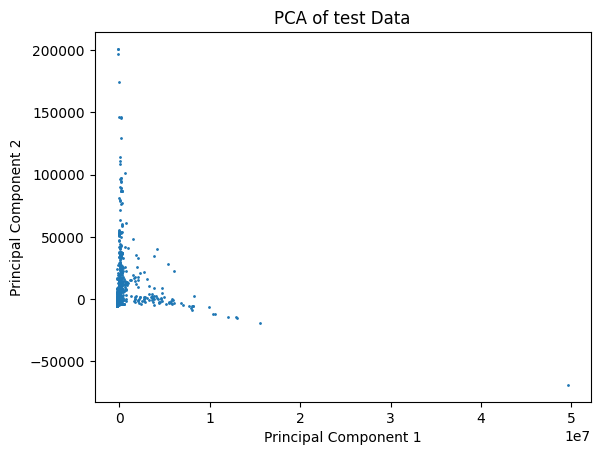

In [73]:
# Reduce to 2D
pcs = PCA(n_components=2)
X_pca = pcs.fit_transform(test)

# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=1)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title("PCA of test Data")
plt.show()

In [27]:
X_sample = normal_test.drop(columns=['Label'])
Y_sample = normal_test['Label']

# X_sample_scaled = scaler.fit_transform(X_sample)

score = 0
total = 200

for i in range(total):
    sample = X_sample.iloc[[i]]  # Must be 2D
    # sample = X_sample[-i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    actual = Y_sample.iloc[-i]

    if pred == actual:
        score += 1
        
    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")

print("Percentage: ", (score/total)*100)

Sample 0: Predicted = 0, Actual = 0
Sample 1: Predicted = 0, Actual = 0
Sample 2: Predicted = 0, Actual = 0
Sample 3: Predicted = 0, Actual = 0
Sample 4: Predicted = 0, Actual = 0
Sample 5: Predicted = 0, Actual = 0
Sample 6: Predicted = 0, Actual = 0
Sample 7: Predicted = 0, Actual = 0
Sample 8: Predicted = 0, Actual = 0
Sample 9: Predicted = 0, Actual = 0
Sample 10: Predicted = 0, Actual = 0
Sample 11: Predicted = 0, Actual = 0
Sample 12: Predicted = 0, Actual = 0
Sample 13: Predicted = 0, Actual = 0
Sample 14: Predicted = 0, Actual = 0
Sample 15: Predicted = 0, Actual = 0
Sample 16: Predicted = 0, Actual = 0
Sample 17: Predicted = 0, Actual = 0
Sample 18: Predicted = 0, Actual = 0
Sample 19: Predicted = 0, Actual = 0
Sample 20: Predicted = 0, Actual = 0
Sample 21: Predicted = 0, Actual = 0
Sample 22: Predicted = 0, Actual = 0
Sample 23: Predicted = 0, Actual = 0
Sample 24: Predicted = 0, Actual = 0
Sample 25: Predicted = 0, Actual = 0
Sample 26: Predicted = 0, Actual = 0
Sample 27: 

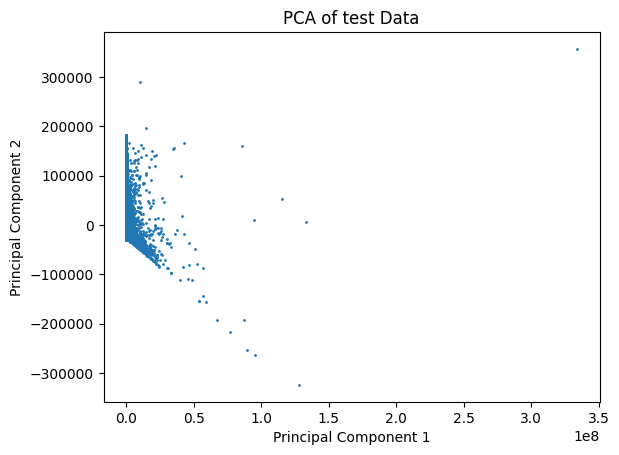

In [76]:
# Reduce to 2D
pcs = PCA(n_components=2)
X_pca = pcs.fit_transform(normal_test)

# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=1)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title("PCA of test Data")
plt.show()

In [30]:
def data_range(data):
    limits = round(data.shape[0]*90/100)
    return data[limits:data.shape[0]]

def classify_attacks(data):
    data['Label'] = data['Label'].replace(['DDoS', 'Web_based', 'DoS', 'Recon', 'Spoofing', 'Mirai'], 1)
    # Ensure labels are integers
    data['Label'] = data['Label'].astype(int)

attack_sample = data_range(Web_based).drop(columns=dropped_columns)
# attack_sample = data_range(DDoS)
classify_attacks(attack_sample)
# attack_sample = attack_test

# attack_sample = pd.read_csv('C:/Users/ADMIN/Downloads/threat_logs.csv', encoding='cp1252', index_col=None, header=0).drop(columns=['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'syn_count', 'fin_count', 'rst_count', 'Telnet', 'SMTP', 'SSH', 'IRC', 'ARP', 'IGMP', 'LLC', 'IAT', 'Number'])

# X_sample = attack_sample
X_sample = attack_sample.drop(columns=['Label'])
Y_sample = attack_sample['Label']

score = 0
total = 50

for i in range(total):
    sample = X_sample.iloc[[i]]  # Must be 2D
    print(sample)
    # sample = X_sample_scaled[i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    actual = Y_sample.iloc[i]

    if pred == actual:
        score += 1
        
    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")
    # print(f"Sample {i}: Predicted = {pred}")

print("Percentage: ", (score/total)*100)

       Header_Length  Protocol Type  Time_To_Live      Rate  syn_flag_number  \
14448           52.0              6    176.666667  0.100051              0.0   

       psh_flag_number  ack_flag_number  ack_count  syn_count  HTTPS  ...  \
14448         0.666667              1.0          3          0    1.0  ...   

       UDP  Tot sum  Min  Max        AVG        Std  Tot size       IAT  \
14448  0.0      290   66  112  96.666667  26.558112       290  0.025933   

       Number    Variance  
14448       3  705.333333  

[1 rows x 23 columns]
Sample 0: Predicted = 1, Actual = 1
       Header_Length  Protocol Type  Time_To_Live         Rate  \
14449           52.0              6         141.4  3635.177369   

       syn_flag_number  psh_flag_number  ack_flag_number  ack_count  \
14449              0.0             0.35              1.0        100   

       syn_count  HTTPS  ...  UDP  Tot sum  Min   Max      AVG          Std  \
14449          0    1.0  ...  0.0   109905   66  2922  1099.05 

### 2nd stage model (multiclass classification)

In [86]:
X_dist_test = attack.drop(columns=['Label'])
Y_dist_test = attack['Label']

In [ ]:
for col in X_dist_test:
    print(col)
    print("Spoofing: ", len(Spoofing[:12522][col]))
    print("Recon: ", len(Recon[:12522][col]))
    print("Mirai: ", len(Mirai[:12522][col]))
    print("DDoS: ", len(DDoS[:12522][col]))
    print("DoS: ", len(DoS[:12522][col]))
    print("Web_based: ", len(Web_based[:12522][col]))
    print("Brute_Force: ", len(Brute_Force[:12522][col]))
    plt.figure(figsize=(10,4))
    sns.kdeplot(Spoofing[:12522][col], label='Spoofing traffic', fill=True)
    sns.kdeplot(Recon[:12522][col], label='Recon traffic', fill=True)
    sns.kdeplot(Mirai[:12522][col], label='Mirai traffic', fill=True)
    sns.kdeplot(DDoS[:12522][col], label='DDoS traffic', fill=True)
    sns.kdeplot(DoS[:12522][col], label='DoS traffic', fill=True)
    sns.kdeplot(Web_based[:12522][col], label='Web_based traffic', fill=True)
    sns.kdeplot(Brute_Force[:12522][col], label='Brute_Force traffic', fill=True)
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()

In [127]:
dropped_columns = ['ICMP', 'IGMP', 'IPv', 'ARP', 'LLC', 'SMTP', 'Telnet', 'ece_flag_number', 'cwr_flag_number', 
                   'DHCP', 'IRC', 'SSH', 'fin_count', 'DNS', 'fin_flag_number', 'TCP', 'HTTP', 'rst_count', 'rst_flag_number']

In [128]:
def limit(data):
    limits = round(data.shape[0]*90/100)
    return limits

attack_train = pd.concat([DDoS[0:limit(DDoS)], DoS[0:limit(DoS)], Mirai[0:limit(Mirai)], Web_based[0:limit(Web_based)], 
                          Spoofing[0:limit(Spoofing)], Recon[0:limit(Recon)]], axis=0, ignore_index=True)
attack_train = attack_train.drop(columns = dropped_columns)
print("Training attack data: ",attack_train.shape)


attack_test = pd.concat([DDoS[limit(DDoS):DDoS.shape[0]], DoS[limit(DoS):DoS.shape[0]], Mirai[limit(Mirai):Mirai.shape[0]], 
                         Web_based[limit(Web_based):Web_based.shape[0]], Spoofing[limit(Spoofing):Spoofing.shape[0]], 
                         Recon[limit(Recon):Recon.shape[0]]], axis=0, ignore_index=True)
attack_test = attack_test.drop(columns = dropped_columns)
print("Testing attack data: ",attack_test.shape)

Training attack data:  (1262935, 21)
Testing attack data:  (140326, 21)


In [129]:
columns_name = attack_train.drop(columns=['Label']).columns

In [ ]:
# Train set preprocessing
attack_train.drop_duplicates(keep='first', inplace = True)
attack_train.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_train.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_train.reset_index(drop=True, inplace=True)

In [130]:
# Create test data
X_train_val = attack_train.drop(columns=['Label'])
Y_train_val = attack_train['Label']

In [131]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
sample_limit = label_series.value_counts()[2]
print(label_series.value_counts())
print(sample_limit)

Label
DDoS         270000
DoS          270000
Mirai        270000
Recon        270000
Spoofing     168487
Web_based     14448
Name: count, dtype: int64
270000


In [ ]:
# Under sampling
undersample = RandomUnderSampler(sampling_strategy={'Recon':sample_limit, 'Spoofing':sample_limit}) # if the sampling_strategy='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
                                                            # the target undersample - in this case '2' is the name of the 'DDOS' after encoded


X_train_val, Y_train_val = undersample.fit_resample(X_train_val, Y_train_val)

In [132]:
# Over sampling
sm = SMOTE()
X_train_val, Y_train_val = sm.fit_resample(X_train_val, Y_train_val)

print(Y_train_val.shape)
print(X_train_val.shape)

(1620000,)
(1620000, 20)


In [133]:
label_series = pd.Series(Y_train_val) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
DDoS         270000
DoS          270000
Mirai        270000
Web_based    270000
Spoofing     270000
Recon        270000
Name: count, dtype: int64


In [28]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_val)

In [134]:
X_train_scaled = X_train_val

In [135]:
# Split the data set into training and testing
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_scaled, Y_train_val, test_size=0.2, random_state=33, shuffle=True)

In [142]:
frst_model = RandomForestClassifier(n_estimators=100,       # Default (reduce to 50-80 if too slow)
                                    max_depth=50,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=100,   # Reduce splits on small nodes
                                    min_samples_leaf=50,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    n_jobs=-1,              # Use all CPU cores
                                    #verbose=1,              # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(X_train, Y_train)

y_pred_frst = frst_model.predict(X_val)
print(classification_report(Y_val, y_pred_frst))

              precision    recall  f1-score   support

        DDoS       0.86      0.77      0.82     54160
         DoS       0.83      0.80      0.82     54249
       Mirai       0.92      0.87      0.90     54078
       Recon       0.71      0.75      0.73     53928
    Spoofing       0.71      0.72      0.72     53931
   Web_based       0.72      0.80      0.75     53654

    accuracy                           0.79    324000
   macro avg       0.79      0.79      0.79    324000
weighted avg       0.79      0.79      0.79    324000



In [143]:
'''
n_estimators=100,       
max_depth=25,           
min_samples_split=15,   
min_samples_leaf=15,    
max_features='sqrt',    
n_jobs=-1,              
#verbose=1,              
random_state=42
'''
X_test = attack_test.drop(columns=['Label'])
Y_test = attack_test['Label']
y_pred_frst_test = frst_model.predict(X_test)
print(classification_report(Y_test, y_pred_frst_test))

              precision    recall  f1-score   support

        DDoS       0.86      0.77      0.82     30000
         DoS       0.83      0.78      0.81     30000
       Mirai       0.92      0.87      0.90     30000
       Recon       0.84      0.75      0.80     30000
    Spoofing       0.63      0.71      0.67     18721
   Web_based       0.11      0.61      0.19      1605

    accuracy                           0.78    140326
   macro avg       0.70      0.75      0.70    140326
weighted avg       0.83      0.78      0.80    140326



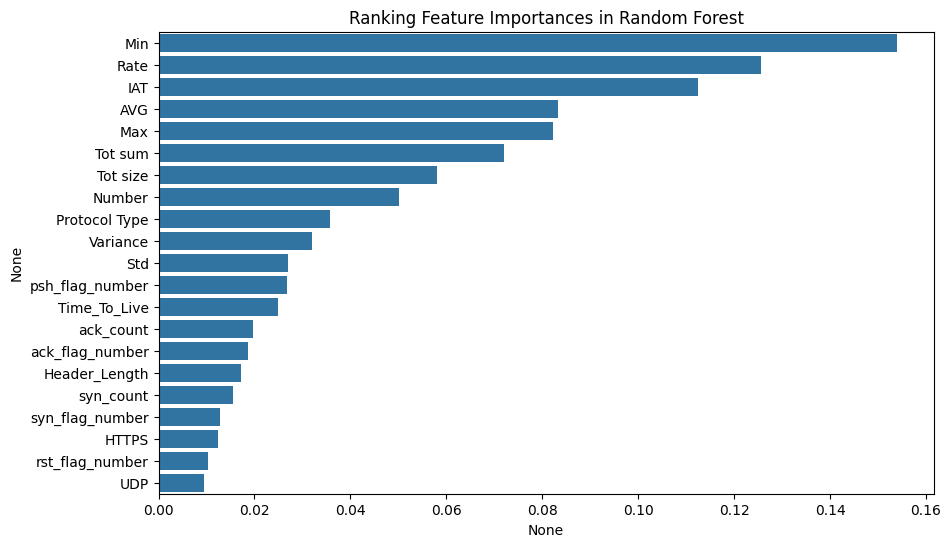

In [47]:
# Check feature importance
feat_importances = pd.Series(frst_model.feature_importances_, index=columns_name)
top_features = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Ranking Feature Importances in Random Forest")
plt.show()

In [151]:
# Save the model
with open('../Models/CIC_models/new_frst_model_2nd_stage.pkl', 'wb') as f:
    pickle.dump(frst_model, f)

In [118]:
# Load the model
with open('../Models/CIC_models/frst_model_2nd_stage.pkl', 'rb') as f:
    frst_model = pickle.load(f)

In [150]:
def data_range(data):
    limits = round(data.shape[0]*90/100)
    return data[limits:data.shape[0]]

attack_sample = data_range(Web_based).drop(columns=dropped_columns)
# attack_sample = data_range(DDoS)
# attack_sample = attack_test
# attack_sample = pd.read_csv('C:/Users/ADMIN/Downloads/DDoS-HTTP_Flood-.pcap.csv', encoding='cp1252', index_col=None, header=0)

# X_sample = attack_sample
X_sample = attack_sample.drop(columns=['Label'])
Y_sample = attack_sample['Label']

score = 0
total = 200

for i in range(total):
    sample = X_sample.iloc[[i]]  # Must be 2D
    # sample = X_sample_scaled[- i].reshape(1, -1)  #If scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    actual = Y_sample.iloc[- i]

    if pred == actual:
        score += 1

    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")
    # print(f"Sample {i}: Predicted = {pred}")

print("Percentage: ", (score/total)*100)

Sample 0: Predicted = Web_based, Actual = Web_based
Sample 1: Predicted = Spoofing, Actual = Web_based
Sample 2: Predicted = Web_based, Actual = Web_based
Sample 3: Predicted = Web_based, Actual = Web_based
Sample 4: Predicted = Recon, Actual = Web_based
Sample 5: Predicted = Web_based, Actual = Web_based
Sample 6: Predicted = Recon, Actual = Web_based
Sample 7: Predicted = Web_based, Actual = Web_based
Sample 8: Predicted = Web_based, Actual = Web_based
Sample 9: Predicted = Spoofing, Actual = Web_based
Sample 10: Predicted = Web_based, Actual = Web_based
Sample 11: Predicted = Web_based, Actual = Web_based
Sample 12: Predicted = Web_based, Actual = Web_based
Sample 13: Predicted = Recon, Actual = Web_based
Sample 14: Predicted = Web_based, Actual = Web_based
Sample 15: Predicted = Web_based, Actual = Web_based
Sample 16: Predicted = Web_based, Actual = Web_based
Sample 17: Predicted = Web_based, Actual = Web_based
Sample 18: Predicted = Web_based, Actual = Web_based
Sample 19: Predic

### Model train on Normal traffic only (Unsupervised learning)

Unsupervised learning for Anomaly Detection using One-Class Classification (or Novelty Detection)

In [ ]:
model = IsolationForest(n_estimators=1000,       # Number of trees in the forest
                            max_samples='auto',        # Number of samples to draw for each tree (sub-sampling)
                            contamination='auto',   
                            random_state=42,
                            n_jobs=-1)              # Use all CPU cores
model.fit(X_train_scaled)

Unsupervised learning for Anomaly Detection using Autoencoder

In [ ]:
import keras
from keras.models import Sequential
from keras import Input, optimizers, layers
from keras.layers import *

In [ ]:
_features = X_train_scaled.shape[1]
print(_features)

In [ ]:
model = Sequential([
    Input(shape=(_features,)),
    
    # Autoencoder
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),   # bottleneck
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(512, activation='relu'),

    # Classification layer
    Dense(_features, activation='sigmoid'),  # Softmax for multiclass, Sigmoid for binary, both use as output layer
])

In [ ]:
model.summary()

In [ ]:
opt = optimizers.Adam(learning_rate=0.0001)
# model.compile(loss='mse', optimizer=opt, metrics=[keras.metrics.F1Score(average=None, threshold=None, name="f1_score", dtype=None)])
model.compile(loss='mse', optimizer=opt)
early_stop_callback = keras.callbacks.EarlyStopping(monitor='loss', patience=5)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                  patience=3, min_lr=0.0001)

In [ ]:
start_fit = time.time()
history = model.fit(X_train_scaled, X_train_scaled,
                    batch_size=256,
                    epochs=50,
                    verbose=True,
                    validation_split= 0.1)    

end_fit = time.time()
fit_time = end_fit - start_fit
print("fit time: {:.2f} seconds".format(fit_time)) 

In [ ]:
#Let's try to get latent learnt representation by autoencoder
hidden_representation = Sequential()
hidden_representation.add(model.layers[0])
hidden_representation.add(model.layers[1])
hidden_representation.add(model.layers[2])
hidden_representation.add(model.layers[3])

In [ ]:
hidden_representation.summary()

In [ ]:
attack_test.drop_duplicates(keep='first', inplace = True)
attack_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_test.reset_index(drop=True, inplace=True)

# attack_test = attack_test.drop(columns=['Tot size', 'Protocol Type'])
# attack_test = attack_test.drop(columns=['Label'])

# # Grouping
# Attack = ['DDoS', 'Web_based', 'DoS', 'Brute_Force', 'Recon', 'Spoofing', 'Mirai']
# def classify_attacks(data):
#     data['Label'].replace(Attack,1,inplace=True)
# classify_attacks(attack_test)

normal_test.drop_duplicates(keep='first', inplace = True)
normal_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
normal_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
normal_test.reset_index(drop=True, inplace=True)

# normal_test = normal_test.drop(columns=['Tot size', 'Protocol Type'])
# normal_test = normal_test.drop(columns=['Label'])

norm_hid_rep = hidden_representation.predict(normal_test)
fraud_hid_rep = hidden_representation.predict(attack_test)

In [ ]:
from sklearn.manifold import TSNE

def tsne_plot(x1, y1, name="graph.png"):
    
    #Scale features to improve the training ability of TSNE.
    standard_scaler = StandardScaler()
    df2_std = standard_scaler.fit_transform(x1)

    tsne = TSNE(n_components=2, random_state=0)
    x_test_2d = tsne.fit_transform(df2_std)
    
    #Build the scatter plot with the two types of transactions.
    color_map = {0:'green', 1:'red'}
    plt.figure()
    for idx, cl in enumerate(np.unique(y1)):
        plt.scatter(x = x_test_2d[y1==cl,0], 
                    y = x_test_2d[y1==cl,1], 
                    c = color_map[idx], 
                    label = cl)
    plt.xlabel('X in t-SNE')
    plt.ylabel('Y in t-SNE')
    plt.legend(loc='upper left')
    plt.title('t-SNE visualization of test data')
    plt.show()

In [ ]:
#Let's try to visualize TSNE again for the learnt representation
rep_x = np.append(norm_hid_rep, fraud_hid_rep, axis = 0)
y_n = np.zeros(norm_hid_rep.shape[0])
y_f = np.ones(fraud_hid_rep.shape[0])
rep_y = np.append(y_n, y_f)

tsne_plot(rep_x, rep_y)

In [ ]:
#Finally we can train a classifier on learnt representations

train_x, val_x, train_y, val_y = train_test_split(rep_x, rep_y, test_size=0.25)
clf = LogisticRegression(solver="lbfgs").fit(train_x, train_y)
pred_y = clf.predict(val_x)

print ("")
print ("Classification Report: ")
print (classification_report(val_y, pred_y))

print ("")
print ("Accuracy Score: ", accuracy_score(val_y, pred_y))

In [ ]:
#Finally we can train a classifier on learnt representations

train_x, val_x, train_y, val_y = train_test_split(rep_x, rep_y, test_size=0.25)
frst_model = RandomForestClassifier(n_estimators=100,       # Default (reduce to 50-80 if too slow)
                                    max_depth=20,           # Limit tree depth to avoid overfitting + speed up
                                    min_samples_split=20,   # Reduce splits on small nodes
                                    min_samples_leaf=20,    # Prevent tiny leaves
                                    max_features='sqrt',    # Faster: only sqrt(features) per split
                                    n_jobs=-1,              # Use all CPU cores
                                    #verbose=1,              # Show progress
                                    random_state=42)        # Reproducibility

frst_model.fit(train_x, train_y)
pred_y = frst_model.predict(val_x)

print ("")
print ("Classification Report: ")
print (classification_report(val_y, pred_y))

print ("")
print ("Accuracy Score: ", accuracy_score(val_y, pred_y))

In [ ]:
# sample_set = attack_test
sample_set = normal_test

# Test set preprocessing
sample_set.drop_duplicates(keep='first', inplace = True)
sample_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
sample_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
sample_set.reset_index(drop=True, inplace=True)

X_sample = sample_set.drop(columns=['Label'])
# X_sample = sample_set.drop(columns=['Label', 'Tot size', 'Protocol Type'])
# Y_sample = sample_set['Label']

X_sample_scaled = scaler.fit_transform(X_sample)

# Step 1: Get reconstruction errors on validation normal traffic
val_reconstructions = model.predict(X_sample_scaled)
val_mse = np.mean(np.power(X_sample_scaled - val_reconstructions, 2), axis=1)

# Step 2: Compute threshold (e.g., 95th percentile)
threshold = np.percentile(val_mse, 50)
print(f"Anomaly Detection Threshold (95th percentile): {threshold:.6f}")

# Step 3: Loop through test samples to classify
for i in range(100):
    # Get i-th test sample (already scaled)
    sample = X_sample_scaled[i].reshape(1, -1)

    # Predict reconstruction
    reconstruction = model.predict(sample)

    # Calculate reconstruction error (MSE)
    mse = np.mean(np.power(sample - reconstruction, 2))

    # Decision based on threshold
    label = "Anomaly Detected!" if mse > threshold else "Normal Traffic."
    
    print(f"Sample {i}: MSE = {mse:.6f} --> {label}")


In [ ]:
# test_set = pd.read_csv('../Label CSV/BENIGN.csv')
# test_set = pd.read_csv('../Label CSV/Mirai.csv')
# test_set = pd.read_csv('../Label CSV/Brute_Force.csv')
# test_set = pd.read_csv('../Label CSV/DDoS.csv')
# test_set = pd.read_csv('../Label CSV/DoS.csv')
# test_set = pd.read_csv('../Label CSV/Recon.csv')
# test_set = pd.read_csv('../Label CSV/Spoofing.csv')
# test_set = pd.read_csv('../Label CSV/Web_based.csv')
test_set = normal_train

# Test set preprocessing
test_set.drop_duplicates(keep='first', inplace = True)
test_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
test_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
test_set.reset_index(drop=True, inplace=True)
test_set = test_set

X_normal_sample = test_set.drop(columns=['Tot size', 'Protocol Type'])
# X_normal_sample = test_set.drop(columns=['Label'])
# Y_normal_sample = test_set['Label']

X_normal_sample_scaled = scaler.fit_transform(X_normal_sample)

for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_normal_sample_scaled[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]
    # actual = Y_normal_sample.iloc[i]

    print(f"Sample {i}: Predicted = {pred}")
    # print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")

# rand = random.randint(0,len(X_scaled)-1)
# test_data = X_scaled[rand].reshape(1, -1)    #If standard scaler is includeed, always reshape the data

# pred_label = model.predict(test_data)
# print("Predicted class label:", pred_label)
# real_label = Y_test.iloc[rand]
# print("Real class label:", real_label)

In [ ]:
# Test set preprocessing
attack_test.drop_duplicates(keep='first', inplace = True)
attack_test.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
attack_test.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
attack_test.reset_index(drop=True, inplace=True)

X_attack_sample = attack_test.drop(columns=['Label'])
Y_attack_sample = attack_test['Label']

X_attack_sample_scaled = scaler.fit_transform(X_attack_sample)

for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_attack_sample_scaled[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = model.predict(sample)[0]
    actual = Y_attack_sample.iloc[i]

    print(f"Sample {i}: Predicted = {pred}, Actual = {actual}")

# rand = random.randint(0,len(X_scaled)-1)
# test_data = X_scaled[rand].reshape(1, -1)    #If standard scaler is includeed, always reshape the data

# pred_label = model.predict(test_data)
# print("Predicted class label:", pred_label)
# real_label = Y_test.iloc[rand]
# print("Real class label:", real_label)

If val loss increases while train loss keeps decreasing, it’s overfitting

In [ ]:
# Assuming 'history' is the result from model.fit()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

In [ ]:
sample_set = pd.read_csv('../Label CSV/BENIGN.csv')
# sample_set = pd.read_csv('../Label CSV/Mirai.csv')
# sample_set = pd.read_csv('../Label CSV/Brute_Force.csv')
# sample_set = pd.read_csv('../Label CSV/DDoS.csv')
# sample_set = pd.read_csv('../Label CSV/DoS.csv')
# sample_set = pd.read_csv('../Label CSV/Recon.csv')
# sample_set = pd.read_csv('../Label CSV/Spoofing.csv')
# sample_set = pd.read_csv('../Label CSV/Web_based.csv')
# sample_set = normal_test

# Test set preprocessing
sample_set.drop_duplicates(keep='first', inplace = True)
sample_set.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
sample_set.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
sample_set.reset_index(drop=True, inplace=True)

# X_sample = sample_set
X_sample = sample_set.drop(columns=['Label'])
Y_sample = sample_set['Label']

X_sample_scaled = scaler.fit_transform(X_sample)

# # Predict Anomaly (-1 = Anomaly, 1 = Normal)
# predictions = model.predict(X_sample_scaled)

# # Optional: Get anomaly scores (the lower, the more anomalous)
# anomaly_scores = model.decision_function(X_sample_scaled)

# print(predictions)
# print(anomaly_scores)

for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = X_sample_scaled[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = model.predict(sample)[0]

    print(f"Sample {i}: Predicted = {pred}")

# rand = random.randint(0,len(X_scaled)-1)
# test_data = X_scaled[rand].reshape(1, -1)    #If standard scaler is includeed, always reshape the data

# pred_label = model.predict(test_data)
# print("Predicted class label:", pred_label)
# real_label = Y_test.iloc[rand]
# print("Real class label:", real_label)

In [ ]:
# Check feature importance
feat_importances = pd.Series(frst_model.feature_importances_, index=columns_name)
top_features = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top Feature Importances in Random Forest")
plt.show()

In [ ]:
my_benign = pd.read_csv('C:/Users/ADMIN/Downloads/live_features.csv')
my_benign = my_benign.drop(columns=['ts'])
# # print(my_benign.info())
# my_benign = my_benign.drop(columns=['ts', 'fin_count', 'fin_flag_number', 'rst_count', 'rst_flag_number', 'syn_count', 'syn_flag_number', 'Number'])
# # Test set preprocessing
# my_benign.drop_duplicates(keep='first', inplace = True)
# my_benign.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
# my_benign.dropna(inplace=True)    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
# my_benign.reset_index(drop=True, inplace=True)
# my_benign = scaler.fit_transform(my_benign)

In [ ]:
for i in range(50):
    # sample = X_test.iloc[[i]]  # Must be 2D
    sample = my_benign[i].reshape(1, -1)  #If standard scaler is includeed, always reshape the data
    pred = frst_model.predict(sample)[0]

    print(f"Sample {i}: Predicted = {pred}")

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
data_combined = pd.concat([cic_benign, my_benign])
data_scaled = scaler.fit_transform(data_combined)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_scaled)

labels = np.array(['CIC'] * len(cic_benign) + ['Mine'] * len(my_benign))

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=labels)
plt.title('PCA of Benign Data')
plt.show()